## 2. Machine Learning for Regression


In [1]:
# 판다스(Pandas) 라이브러리를 임포트합니다.
# 판다스는 엑셀 표처럼 행과 열로 이루어진 '데이터프레임(DataFrame)' 구조를 다루게 해주는 핵심 도구입니다.
# 코드 전체에서 길게 타이핑하는 대신 'pd'라는 짧은 별칭(Alias)으로 편하게 부르기 위해 'as pd'를 붙입니다.
import pandas as pd

# 넘파이(NumPy) 라이브러리를 임포트합니다.
# 넘파이는 대규모 다차원 배열과 수학·행렬 연산을 초고속으로 처리할 수 있게 도와주는 수치 계산 전문 도구입니다.
# 마찬가지로 앞으로 'np'라는 별칭으로 호출하겠다고 선언하는 것입니다.
import numpy as np

## 2.2 Data preparation

In [2]:
# 분석에 사용할 자동차 가격 데이터셋(CSV 파일)이 공개되어 있는 인터넷상의 원본 URL 주소입니다.
# 이 긴 문자열 주소를 앞으로 다루기 쉽도록 'data'라는 이름의 변수 상자에 담아둡니다.
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [3]:
# urllib.request 모듈에서 파일을 내려받는 urlretrieve 함수를 가져옵니다.
# 이 함수는 인터넷 URL에 있는 파일을 내 컴퓨터의 지정한 경로로 받아 저장합니다.
# 윈도우에는 강의에서 쓰는 wget이 기본 설치되어 있지 않아서, 같은 일을 파이썬으로 대신합니다. (강의 원본은 !wget $data)
from urllib.request import urlretrieve

# 앞 셀의 data 변수에 담긴 CSV URL에서 파일을 받아, 노트북 작업 폴더에 'data.csv'로 저장합니다.
# 저장 파일 이름이 data.csv이므로, 다음 셀의 pd.read_csv('data.csv')가 그대로 동작합니다.
urlretrieve(data, 'data.csv')


('data.csv', <http.client.HTTPMessage at 0x15fa3c09250>)

In [4]:
# 방금 다운로드 완료된 'data.csv' 파일을 판다스의 'read_csv' 함수로 읽어 들입니다.
# 컴퓨터 메모리 위에 이 파일이 엑셀 표 형태의 '데이터프레임(DataFrame)' 객체로 변환되어 올라가며,
# 앞으로 이 표를 자유롭게 조작할 수 있도록 'df'라는 이름의 변수에 대입합니다.
df = pd.read_csv('data.csv')

In [5]:
# 데이터프레임의 모든 열(컬럼) 이름을 일제히 소문자로 바꾸고, 이름 속 공백은 밑줄(_)로 바꿉니다.
# 기계학습 코드에서는 열 이름을 점(.)으로 접근하는 경우가 많아서, 공백이 있으면 문법 오류가 납니다.
# '.str'은 문자열 전용 메서드 묶음이고, 메서드를 연달아 붙이는 방식(체이닝)으로 한 줄에 두 가지 변환을 끝냅니다.
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
# 'make'(제조사) 열의 각 값을 소문자로 바꾸고, 값 안의 공백도 밑줄로 바꿉니다.
# 위 셀에서 열 이름을 정규화한 것과 같은 방식으로, 이번에는 실제 데이터 값(브랜드명)을 시험 삼아 변환해 보는 것입니다.
# 결과를 변수에 저장하지 않았으므로 변환된 시리즈가 출력만 되고, 원본 df는 아직 바뀌지 않습니다.
df['make'].str.lower().str.replace(' ', '_')

0            bmw
1            bmw
2            bmw
3            bmw
4            bmw
          ...   
11909      acura
11910      acura
11911      acura
11912      acura
11913    lincoln
Name: make, Length: 11914, dtype: str

In [7]:
# 데이터 타입이 'object'(문자열)인 열만 골라, 그 열 이름들의 목록을 만듭니다.
# df.dtypes는 각 열이 숫자인지 문자인지 알려 주는 시리즈이고, 조건으로 걸러 낸 뒤 .index로 열 이름만 꺼냅니다.
# 이 이름 목록을 다음 셀의 for 반복문에서 한꺼번에 정규화하려고 'strings' 변수에 담아 둡니다.
strings = list(df.dtypes[df.dtypes == 'object'].index)

# 방금 만든 문자열 열 이름 목록을 노트북에 출력해, 어떤 열이 범주형(문자)인지 눈으로 확인합니다.
strings

[]

In [8]:
# 앞에서 모아 둔 문자열 열 이름들을 하나씩 꺼내며 반복합니다.
# 각 열의 실제 값에 소문자 변환과 공백→밑줄 치환을 적용하고, 그 결과를 같은 열에 다시 덮어씁니다.
# 이제 제조사·모델명 같은 범주 값이 모두 일정한 형식이 되어, 나중에 비교하거나 더미 변수로 만들기 쉬워집니다.
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [9]:
# 각 열이 정수인지, 실수인지, 문자열(object)인지 데이터 타입 표를 출력합니다.
# 전처리 직후 타입이 기대와 맞는지, 범주형과 수치형을 어떻게 나눠 쓸지 한눈에 점검하는 단계입니다.
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## 2.3 Exploratory data analysis

In [10]:
# 데이터프레임의 모든 열을 하나씩 순회하면서, 그 열의 특성을 짧게 훑어봅니다.
for col in df.columns:
    # 지금 살펴보고 있는 열 이름을 먼저 출력합니다.
    print(col)
    # unique()는 중복을 제거한 고유값 배열이고, 앞에서 5개만 잘라 샘플을 보여 줍니다.
    print(df[col].unique()[:5])
    # nunique()는 그 열에 서로 다른 값이 몇 종류인지 세어, 범주의 다양성을 가늠하게 합니다.
    print(df[col].nunique())
    # 열과 열 사이에 빈 줄을 넣어 출력이 서로 붙지 않게 읽기 쉽게 만듭니다.
    print()

make
<StringArray>
['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1 Series M', '1 Series', '100', '124 Spider', '190-Class']
Length: 5, dtype: str
915

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/E85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL', 'DIRECT_DRIVE', 'UNKNOWN']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['Factory Tuner,Luxury,High-Performance',
                    'Luxury,Performance',
               'Luxury,High-Pe

In [11]:
# 전처리가 반영된 데이터프레임 전체를 노트북에 출력합니다.
# 앞부분 행과 열을 눈으로 확인하며, 열 이름과 값이 소문자·밑줄 형식으로 바뀌었는지 점검합니다.
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


Distribution of price

In [12]:
# 맷플롯립(Matplotlib)의 파이플롯 모듈을 임포트합니다.
# 그래프를 그리는 가장 기본이 되는 시각화 도구이며, 앞으로 'plt'라는 별칭으로 호출합니다.
import matplotlib.pyplot as plt

# 시본(Seaborn) 라이브러리를 임포트합니다.
# 맷플롯립 위에 얹혀 통계 그래프를 더 예쁘고 간단하게 그려 주는 시각화 도구이며, 'sns'라는 별칭을 씁니다.
import seaborn as sns

# 주피터 노트북 안에서 그래프를 별도 창이 아니라 셀 바로 아래에 인라인으로 표시하도록 설정합니다.
# 최신 주피터에서는 기본값인 경우가 많지만, 강의 코드와의 호환을 위해 명시적으로 켜 둡니다.
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

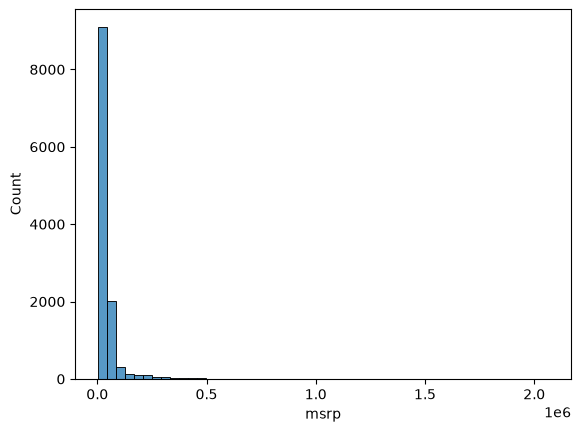

In [13]:
# 시본의 히스토그램(histplot)으로 자동차 권장소비자가격(msrp)의 분포를 그립니다.
# bins=50은 가로축을 50개 구간으로 나눠 막대 개수를 정하는 설정입니다.
# 가격처럼 오른쪽으로 길게 늘어진(롱테일) 분포인지 한눈에 보기 위한 첫 그래프입니다.
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

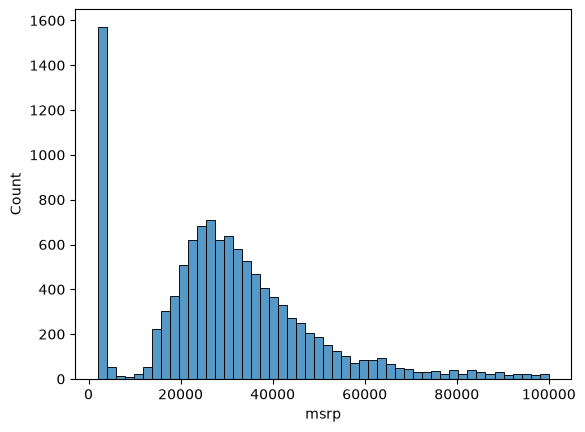

In [14]:
# 가격이 10만 달러 미만인 차량만 골라 다시 히스토그램을 그립니다.
# 초고가 차량이 가로축을 밀어 대부분의 차가 왼쪽에 뭉쳐 보이던 문제를 덜어, 본진 분포를 더 잘 보게 합니다.
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [15]:
# 넘파이의 log1p 함수에 샘플 숫자 리스트를 넣어, 로그 변환 결과를 확인합니다.
# log1p(x)는 log(x + 1)과 같아서, 값이 0이어도 로그가 터지지 않습니다(log(0)은 정의되지 않음).
# 가격처럼 스케일이 큰 숫자를 모델이 다루기 쉬운 범위로 압축하는 전처리의 맛보기입니다.
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [16]:
# 같은 값들에 대해 직접 1을 더한 뒤 일반 로그(np.log)를 적용해 봅니다.
# 결과가 바로 위 log1p와 같다는 것을 보여 주는 비교 실험입니다.
np.log([0 + 1, 1+ 1, 10 + 1, 1000 + 1, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51292546])

In [17]:
# 실제 가격 열(msrp) 전체에 log1p 변환을 적용합니다.
# 롱테일 가격 분포를 종 모양에 가깝게 만들어 선형 회귀가 더 잘 맞도록 하기 위한 단계입니다.
# 변환된 로그 가격 배열을 이후 그래프와 타깃 변수로 쓰려고 'price_logs'에 담습니다.
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

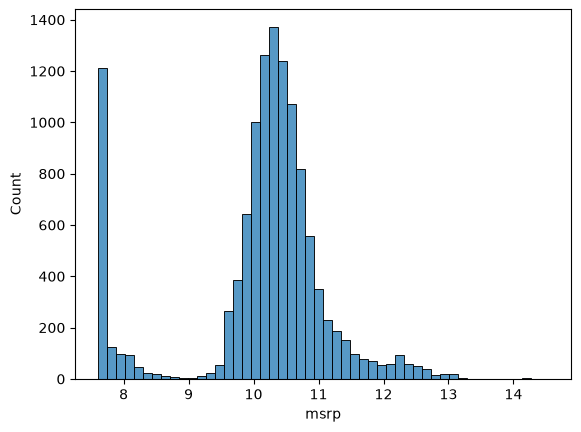

In [18]:
# 로그 변환된 가격의 히스토그램을 그립니다.
# 변환 전에는 한쪽으로 치우쳤던 분포가, 변환 후 얼마나 정규분포에 가까워졌는지 눈으로 비교합니다.

sns.histplot(price_logs, bins=50)

Missing values

In [19]:
# 각 열마다 결측값(NaN)이 몇 개인지 합계를 냅니다.
# 나중에 모델에 넣기 전에 어떤 열을 채우거나 버려야 하는지 파악하는 품질 점검입니다.
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## 2.4 Setting up the validation framework

Let's draw it

In [20]:
# 전체 데이터 행 개수를 n에 저장합니다.
# 이 n을 기준으로 훈련/검증/테스트 비율을 나눌 것입니다.
n = len(df)

# 전체의 20%를 검증(validation) 세트 크기로 잡습니다.
# int()로 소수점을 버려 정수 개수가 되게 합니다.
n_val = int(n * 0.2)

# 마찬가지로 전체의 20%를 테스트 세트 크기로 잡습니다.
n_test = int(n * 0.2)

# 남은 나머지(약 60%)를 훈련 세트 크기로 둡니다.
# 20%+20%를 먼저 정수로 자른 뒤 빼므로, 세 집합 개수의 합이 정확히 n과 같아집니다.
n_train = n - n_val - n_test

In [21]:
# 전체 행 수 n을 출력해, 분할 계산의 기준이 되는 숫자를 확인합니다.
n

11914

In [22]:
# 검증·테스트·훈련 세트의 행 개수를 나란히 출력합니다.
# 대략 20% / 20% / 60%로 나뉘었는지, 세 숫자의 합이 n과 같은지 점검합니다.
n_val, n_test, n_train

(2382, 2382, 7150)

In [23]:
# iloc는 정수 위치(몇 번째 행인지)로 행을 고르는 인덱서입니다.
# 10, 0, 3, 5번째 행을 원하는 순서대로 뽑아, 위치 기반 선택이 어떻게 작동하는지 보여 줍니다.
df.iloc[[10, 0, 3, 5]]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10,BMW,1 Series,2013,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,39600
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
5,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,31200


In [24]:
# 아직 섞지 않은 상태라, 앞부분 n_train행을 그대로 훈련 세트로 자릅니다.
# 데이터가 가격이나 브랜드 순으로 정렬되어 있으면 이 방식은 편향이 생기므로, 바로 다음에서 셔플로 고칩니다.
df_train = df.iloc[:n_train]

# 그다음 n_val행을 검증 세트로 자릅니다.
df_val = df.iloc[n_train:n_train+n_val]

# 나머지 뒷부분을 테스트 세트로 자릅니다.
df_test = df.iloc[n_train+n_val:]

In [25]:
# 0부터 n-1까지의 정수 배열을 만듭니다.
# 이 인덱스 배열을 섞은 뒤, 그 순서로 행을 재배치해 무작위 분할을 구현합니다.
idx = np.arange(n)

In [26]:
# 난수 씨앗(seed)을 2로 고정합니다.
# 같은 씨앗이면 셔플 결과가 항상 같아져, 강의와 숙제에서 숫자가 재현됩니다.
np.random.seed(2)

# idx 배열의 순서를 제자리(in-place)에서 무작위로 섞습니다.
# 원본 데이터프레임은 건드리지 않고, '몇 번째 행을 어떤 세트에 넣을지'만 뒤섞는 것입니다.
np.random.shuffle(idx)

In [27]:
# 섞인 인덱스 앞부분으로 훈련 세트를 다시 만듭니다.
# df.iloc[idx[:n_train]]은 섞인 번호 순서대로 행을 골라 새 데이터프레임을 만듭니다.
df_train = df.iloc[idx[:n_train]]

# 섞인 인덱스의 가운데 구간으로 검증 세트를 만듭니다.
df_val = df.iloc[idx[n_train:n_train+n_val]]

# 섞인 인덱스의 마지막 구간으로 테스트 세트를 만듭니다.
df_test = df.iloc[idx[n_train+n_val:]]

In [28]:
# 훈련 세트의 앞부분 몇 행을 출력합니다.
# 셔플 후 행 순서가 원래와 달라졌는지, 열은 그대로인지 확인합니다.
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385,14410
6720,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031,19685
5878,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640,19795
11190,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873,2000
4554,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657,56260


In [29]:
# 세 세트의 실제 행 개수를 출력합니다.
# n_train, n_val, n_test와 일치하는지 최종 확인합니다.
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [30]:
# 훈련 세트의 행 번호를 0부터 다시 매깁니다.
# drop=True는 옛 인덱스를 새 열로 남기지 않고 버리라는 뜻입니다.
df_train = df_train.reset_index(drop=True)

# 검증 세트도 마찬가지로 인덱스를 0부터 재설정합니다.
df_val = df_val.reset_index(drop=True)

# 테스트 세트도 인덱스를 0부터 재설정합니다.
df_test = df_test.reset_index(drop=True)

In [31]:
# 훈련 세트의 가격(msrp)을 넘파이 배열로 꺼낸 뒤 log1p로 변환해 타깃 벡터 y_train을 만듭니다.
# .values는 판다스 시리즈에서 순수 숫자 배열만 추출해, 이후 행렬 연산에 쓰게 합니다.
y_train = np.log1p(df_train.msrp.values)

# 검증 세트의 로그 가격 타깃을 같은 방식으로 만듭니다.
y_val = np.log1p(df_val.msrp.values)

# 테스트 세트의 로그 가격 타깃을 같은 방식으로 만듭니다.
y_test = np.log1p(df_test.msrp.values)

In [32]:
# 훈련 데이터프레임에서 가격 열을 삭제합니다.
# 특성(X) 쪽에 정답(y)이 남아 있으면 모델이 답을 그대로 보게 되므로, 타깃은 y에만 두고 표에서는 제거합니다.
del df_train['msrp']

# 검증 세트에서도 가격 열을 삭제합니다.
del df_val['msrp']

# 테스트 세트에서도 가격 열을 삭제합니다.
del df_test['msrp']

In [33]:
# 훈련 타깃 벡터의 길이를 출력합니다.
# 훈련 세트 행 수와 같아야 특성 행렬과 짝이 맞습니다.
len(y_train)

7150

## 2.5 Linear regression

draw

In [34]:
# 훈련 세트의 10번째 행(iloc 기준)을 시리즈로 출력합니다.
# 이후 선형 회귀 예제에서 쓸 샘플 차량의 특성(마력, 연식 등)을 눈으로 확인합니다.
df_train.iloc[10]

make                                 Rolls-Royce
model                     Phantom Drophead Coupe
year                                        2015
engine_fuel_type     premium unleaded (required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      AUTOMATIC
driven_wheels                   rear wheel drive
number_of_doors                              2.0
market_category        Exotic,Luxury,Performance
vehicle_size                               Large
vehicle_style                        Convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [35]:
# 2. 단일 차량 데이터로 선형 회귀 함수 구현하기

In [36]:
# 샘플 차량의 특성 벡터 xi를 손으로 만듭니다. (강의에서 고른 마력·연식 관련 값·인기도 세 숫자)
# 이 작은 리스트로 '한 대의 차에 가중치를 곱해 가격을 예측하는' 식을 먼저 이해합니다.
xi = [453, 11, 86]

# 편향(bias, 절편) w0입니다.
# 특성이 모두 0일 때의 기본 예측값에 해당하며, 로그 가격 스케일의 상수항입니다.
w0 = 7.17

# 각 특성에 곱해질 가중치(기울기) 리스트 w입니다.
# xi의 세 값과 짝을 이루어 w[j] * xi[j]를 더하게 됩니다.
w = [0.01, 0.04, 0.002]

In [37]:
# 한 대의 차량 특성 벡터 xi를 받아 선형 회귀 예측값을 계산하는 함수를 정의합니다.
# 공식은 pred = w0 + w1*x1 + w2*x2 + ... 이며, 아직 행렬이 아니라 파이썬 반복문으로 구현합니다.
def linear_regression(xi):
    n = len(xi)

    # 예측값을 절편 w0에서 시작합니다.
    pred = w0

    # 특성마다 가중치를 곱해 예측값에 더합니다. (내적, dot product)
    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [38]:
# 같은 샘플 특성 벡터를 다시 준비합니다.
# 함수를 고친 뒤에도 같은 입력으로 예측이 재현되는지 보려고 값을 다시 넣습니다.
xi = [453, 11, 86]

# 절편 w0을 다시 설정합니다.
w0 = 7.17

# 가중치 벡터 w를 다시 설정합니다.
w = [0.01, 0.04, 0.002]

In [39]:
# 방금 정의한 선형 회귀 함수에 샘플 차량 xi를 넣어 예측값(로그 가격)을 계산합니다.
linear_regression(xi)

12.312

In [40]:
# expm1은 exp(x) - 1, 즉 log1p의 역함수입니다.
# 모델이 내놓은 로그 가격을 다시 달러 단위의 원래 가격으로 되돌릴 때 사용합니다.
np.expm1(12.312)

np.float64(222347.2221101062)

In [41]:
# 방금 되돌린 달러 가격에 다시 log1p를 적용합니다.
# 결과가 원래 로그값 12.312로 돌아오는지 확인하는 왕복 점검입니다.
np.log1p(222347.2221101062)

np.float64(12.312)

## 2.6 Linear regression vector form

In [42]:
# 두 벡터 xi와 w의 내적(각 원소끼리 곱한 뒤 합)을 계산하는 함수를 정의합니다.
# 선형 회귀의 '가중치 곱의 합'을 별도 함수로 빼 두면, 절편을 포함하는 형태로 식을 다시 쓰기 쉽습니다.
def dot(xi, w):
    n = len(xi)
    
    # 누적 합을 실수 0.0에서 시작합니다.
    res = 0.0
    
    # 같은 위치의 특성과 가중치를 곱해 더합니다.
    for j in range(n):
        res = res + xi[j] * w[j]
    
    return res

In [43]:
# 선형 회귀를 '절편 + 내적' 한 줄로 다시 정의합니다.
# 앞에서 만든 dot 함수를 재사용해, 예측이 w0 + <xi, w>와 같음을 보여 줍니다.
def linear_regression(xi):
    return w0 + dot(xi, w)

In [44]:
# 절편 w0을 가중치 리스트 맨 앞에 붙여 하나의 벡터 w_new로 합칩니다.
# 특성 쪽에도 1을 붙이면, 내적 한 번으로 절편과 가중치 곱을 모두 처리할 수 있습니다.
w_new = [w0] + w

In [45]:
# 합쳐진 가중치 벡터 w_new를 출력해, 맨 앞이 절편인지 확인합니다.
w_new

[7.17, 0.01, 0.04, 0.002]

In [46]:
# 특성 벡터 앞에 1을 붙인 뒤, 확장된 가중치 w_new와 내적하는 형태로 함수를 다시 정의합니다.
# xi = [1] + xi 가 바로 '절편 항'을 특성처럼 취급하는 트릭입니다.
def linear_regression(xi):
    # 편향에 해당하는 상수 특성 1을 맨 앞에 붙입니다.
    xi = [1] + xi
    return dot(xi, w_new)

In [47]:
# 확장된 정의로 같은 샘플 xi의 예측값을 다시 계산합니다.
# 이전 구현과 같은 숫자가 나와야 두 표기가 동치임을 확인할 수 있습니다.
linear_regression(xi)

12.312

In [48]:
# 절편과 가중치를 다시 준비하고, 앞에 절편을 붙인 w_new를 만듭니다.
# 다음 셀에서 여러 대의 차를 행렬로 한꺼번에 예측할 때 이 벡터를 씁니다.
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [49]:
# 첫 번째 차량의 특성 행입니다. 맨 앞의 1은 절편용 상수 특성입니다.
x1  = [1, 148, 24, 1385]

# 두 번째 차량의 특성 행입니다. 역시 맨 앞에 1이 붙어 있습니다.
x2  = [1, 132, 25, 2031]

# 열 번째(예제) 차량의 특성 행입니다.
x10 = [1, 453, 11, 86]

# 세 대의 차를 리스트의 리스트(행렬처럼 생긴 파이썬 구조)로 모읍니다.
X = [x1, x2, x10]

# 파이썬 리스트를 넘파이 배열로 바꿔, 행렬 곱셈을 할 수 있게 합니다.
X = np.array(X)

# 만들어진 특성 행렬 X를 출력해 행(차량)·열(특성) 모양을 확인합니다.
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [50]:
# 여러 대의 차를 한 번에 예측하도록, 행렬-벡터 곱으로 선형 회귀를 다시 정의합니다.
# X.dot(w_new)는 각 행(차량)마다 내적을 계산한 예측값 배열을 돌려줍니다.
def linear_regression(X):
    return X.dot(w_new)

In [51]:
# 세 대 차량이 담긴 행렬 X로 예측값 세 개를 한 번에 계산합니다.
linear_regression(X)

array([12.38 , 13.552, 12.312])

## 2.7 Training a linear regression model

In [52]:
# 특성 행렬 X와 타깃 y를 받아 가중치를 학습하는 함수의 빈 껍데기를 먼저 선언합니다.
# pass는 '아직 본문은 비어 있다'는 자리 표시이며, 아래에서 공식을 채울 예정입니다.
def train_linear_regression(X, y):
    pass

In [53]:
# 절편이 아직 붙지 않은 작은 특성 행렬을 손으로 만듭니다.
# 각 행은 한 대의 차, 각 열은 특성(마력, 연식 관련 값, 인기도 등)입니다.
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

# 리스트를 넘파이 배열로 변환합니다.
X = np.array(X)

# 배열 모양과 값을 출력해 확인합니다.
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [54]:
# 행 개수만큼 1.0으로 채워진 벡터를 만듭니다.
# 이 'ones' 열이 곧 절편 w0에 곱해지는 상수 특성입니다.
ones = np.ones(X.shape[0])

# 1로만 된 벡터를 출력해 길이가 행 수와 같은지 확인합니다.
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [55]:
# ones 열을 기존 특성 행렬 X의 맨 왼쪽에 붙여 새 행렬을 만듭니다.
# column_stack은 여러 1차원/2차원 배열을 세로 열 방향으로 합치는 함수입니다.
X = np.column_stack([ones, X])

In [56]:
# 예제용 타깃(가격) 리스트 y를 준비합니다.
# 행 수(9대)와 길이가 같아야 정규방정식으로 가중치를 풀 수 있습니다.
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [57]:
# 그램 행렬 XᵀX를 계산합니다. (특성끼리의 내적 행렬)
# 정규방정식의 왼쪽에 해당하는 정사각 행렬입니다.
XTX = X.T.dot(X)

# XᵀX의 역행렬을 구합니다.
# 이 역행렬이 존재해야 닫힌 해(closed-form)로 가중치를 얻을 수 있습니다.
XTX_inv = np.linalg.inv(XTX)

# 정규방정식 w = (XᵀX)⁻¹ Xᵀ y 로 전체 가중치 벡터를 한 번에 구합니다.
# w_full의 첫 원소가 절편, 나머지가 각 특성의 가중치입니다.
w_full = XTX_inv.dot(X.T).dot(y)

In [58]:
# 학습된 벡터에서 첫 원소를 절편 w0으로 분리합니다.
w0 = w_full[0]

# 나머지 원소를 특성 가중치 벡터 w로 분리합니다.
w = w_full[1:]

In [59]:
# 분리한 절편과 가중치를 출력해 학습 결과를 확인합니다.
w0, w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [60]:
# 정규방정식으로 선형 회귀를 학습하는 함수를 완성합니다.
# 입력 X에 1열을 붙인 뒤 w = (XᵀX)⁻¹ Xᵀ y 를 계산하고, 절편과 가중치를 나눠 반환합니다.
def train_linear_regression(X, y):
    # 행 수만큼의 1 벡터를 만들어 절편 열로 씁니다.
    ones = np.ones(X.shape[0])
    # 절편 열을 특성 행렬 왼쪽에 붙입니다.
    X = np.column_stack([ones, X])

    # 그램 행렬과 그 역행렬, 그리고 정규방정식으로 가중치 전체를 구합니다.
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [61]:
# 방금 만든 학습 함수에 예제 행렬과 타깃 y를 넣어 절편·가중치를 구합니다.
# 바로 위 셀에서 X에 이미 1로 된 절편 열을 붙였고, 함수 안에서도 ones를 한 번 더 붙입니다.
# 같은 열을 두 번 넣으면 XᵀX가 특이행렬이 되어 최신 넘파이는 LinAlgError를 냅니다.
# 그래서 첫 열(절편)을 빼고 특성만 넘깁니다. 함수가 그 안에서 1열을 다시 붙입니다.
train_linear_regression(X[:, 1:], y)


(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

## 2.8 Car price baseline model

In [62]:
# 훈련 세트의 열 이름 목록을 출력합니다.
# 다음 셀에서 모델에 넣을 기본 수치 특성(base)을 고를 때 참고합니다.
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [63]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385
1,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031
2,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640
3,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873
4,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,BMW,4 Series,2015,premium unleaded (required),300.0,6.0,AUTOMATIC,rear wheel drive,2.0,"Luxury,Performance",Midsize,Convertible,31,20,3916
7146,Volkswagen,Beetle,2015,premium unleaded (recommended),210.0,4.0,AUTOMATED_MANUAL,front wheel drive,2.0,"Hatchback,Performance",Compact,2dr Hatchback,30,24,873
7147,GMC,Sierra 1500,2015,flex-fuel (unleaded/E85),285.0,6.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Extended Cab Pickup,22,17,549
7148,Rolls-Royce,Ghost,2014,premium unleaded (required),563.0,12.0,AUTOMATIC,rear wheel drive,4.0,"Exotic,Luxury,Performance",Large,Sedan,21,13,86


In [64]:
# 첫 모델에 쓸 기본 수치 특성 다섯 개를 리스트로 고릅니다.
# 마력, 기통 수, 고속도로·도심 연비, 인기도처럼 숫자로 바로 쓸 수 있는 열입니다.
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

# 고른 열만 추출하고, 결측은 0으로 채운 뒤 넘파이 배열로 바꿉니다.
# fillna(0)은 '정보 없음'을 0으로 두는 단순 전략이며, 이후 prepare_X에서도 같은 방식을 씁니다.
X_train = df_train[base].fillna(0).values

# 훈련 특성으로 선형 회귀를 학습해 절편 w0과 가중치 w를 얻습니다.
w0, w = train_linear_regression(X_train, y_train)

# 학습에 쓴 같은 X_train으로 예측값 y_pred를 만듭니다. (훈련 세트 위 적합 결과)
y_pred = w0 + X_train.dot(w)

In [65]:
# 학습된 절편 w0을 출력합니다.
w0

np.float64(7.927257388069986)

In [66]:
# 학습된 특성 가중치 벡터 w를 출력합니다.
w

array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
       -9.06908672e-06])

<Axes: ylabel='Count'>

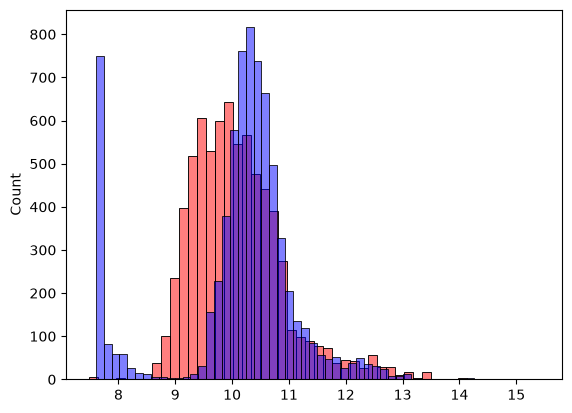

In [67]:
# 예측값(로그 가격)의 분포를 빨간색 히스토그램으로 그립니다.
# alpha=0.5는 반투명으로 겹쳐 그려, 두 분포가 얼마나 겹치는지 보게 합니다.
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)

# 실제 훈련 타깃의 분포를 파란색으로 같은 그림 위에 겹쳐 그립니다.
# 두 봉우리가 비슷하면 모델이 가격 분포를 대략 따라가고 있다는 뜻입니다.
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

## 2.9 RMSE

In [68]:
# 실제값 y와 예측값 y_pred 사이의 RMSE(평균제곱근오차)를 계산하는 함수를 정의합니다.
# 오차를 제곱해 평균 낸 뒤 제곱근을 취하므로, 타깃과 같은 단위로 평균적인 빗나감을 요약합니다.
def rmse(y, y_pred):
    # 각 샘플의 오차를 제곱합니다. (음수 오차도 양수로 바뀜)
    se = (y - y_pred) ** 2
    # 제곱 오차의 평균, 즉 MSE입니다.
    mse = se.mean()
    # MSE의 제곱근이 RMSE입니다.
    return np.sqrt(mse)

In [69]:
# 훈련 세트에서 RMSE를 계산해, 모델이 학습 데이터를 얼마나 맞췄는지 숫자로 확인합니다.
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

## 2.10 Validating the model

In [70]:
# 데이터프레임을 모델이 먹을 수 있는 숫자 행렬 X로 바꾸는 전처리 함수를 정의합니다.
# 기본 수치 열만 고르고 결측을 채운 뒤 .values로 넘파이 배열을 반환합니다.
def prepare_X(df):
    # 미리 정해 둔 base 열만 추출합니다.
    df_num = df[base]
    # 결측값(NaN)을 0으로 채웁니다. 선형 대수 연산은 NaN을 허용하지 않기 때문입니다.
    df_num = df_num.fillna(0)
    # 판다스 표를 순수 숫자 배열로 변환합니다.
    X = df_num.values
    return X

In [71]:
# 훈련 세트를 행렬로 바꾸고 선형 회귀를 학습합니다.
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

# 같은 전처리를 검증 세트에 적용합니다. (학습과 평가에 동일한 변환을 쓰는 것이 중요합니다)
X_val = prepare_X(df_val)

# 검증 특성으로 예측한 뒤, 검증 RMSE를 계산합니다.
# 훈련 오차가 아니라 못 본 데이터 오차라서, 일반화 성능의 첫 지표가 됩니다.
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.761653099130156)

## 2.11 Simple feature engineering

In [72]:
# 차량 나이(age) 특성을 추가하는 쪽으로 prepare_X를 확장합니다.
# 원본 df를 직접 바꾸지 않도록 복사본에서 작업합니다.
def prepare_X(df):
    # 호출자가 넘긴 표를 수정하지 않도록 복사합니다.
    df = df.copy()
    
    # 데이터셋 기준 연도 2017에서 제조 연도를 빼 나이를 만듭니다.
    df['age'] = 2017 - df['year']
    # 기존 수치 특성에 나이를 덧붙인 목록입니다.
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [73]:
# 나이가 포함된 특성으로 다시 학습합니다.
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

# 검증 세트에도 같은 전처리를 적용한 뒤 RMSE를 계산합니다.
# 나이 특성이 들어갔을 때 오차가 줄었는지 비교하는 실험입니다.
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5172055461058299)

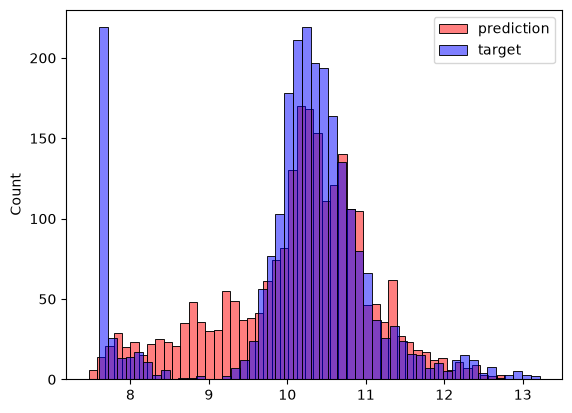

In [74]:
# 검증 예측 분포를 빨간색으로, 실제 검증 타깃을 파란색으로 겹쳐 그립니다.
# label을 붙여 범례에 'prediction' / 'target'이 표시되게 합니다.
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)

# 범례를 켜서 색과 의미를 연결해 줍니다.
plt.legend()

## 2.12 Categorical variables

In [75]:
# 원-핫 인코딩에 쓸 범주형 열 이름 목록입니다.
# 제조사, 모델, 연료, 구동방식, 마켓 카테고리, 크기, 스타일처럼 문자 값인 열입니다.
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

# 각 범주 열에서 '상위 몇 개 값'만 모아 둘 딕셔너리를 준비합니다.
categorical = {}

# 열마다 훈련 세트에서 가장 자주 등장하는 값 5개의 이름을 저장합니다.
# value_counts().head()는 빈도 상위 5개이고, .index가 그 범주 이름 목록입니다.
for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)
categorical

{'make': ['Chevrolet', 'Ford', 'Volkswagen', 'Toyota', 'Dodge'],
 'model': ['Silverado 1500', 'Tundra', 'F-150', 'Sierra 1500', 'Tacoma'],
 'engine_fuel_type': ['regular unleaded',
  'premium unleaded (required)',
  'premium unleaded (recommended)',
  'flex-fuel (unleaded/E85)',
  'diesel'],
 'driven_wheels': ['front wheel drive',
  'rear wheel drive',
  'all wheel drive',
  'four wheel drive'],
 'market_category': ['Crossover',
  'Flex Fuel',
  'Luxury',
  'Hatchback',
  'Luxury,Performance'],
 'vehicle_size': ['Compact', 'Midsize', 'Large'],
 'vehicle_style': ['Sedan',
  '4dr SUV',
  'Coupe',
  'Convertible',
  '4dr Hatchback']}

In [76]:
# 나이, 문 개수 더미, 범주 더미까지 넣어 특성 행렬을 만드는 prepare_X입니다.
# 범주 값은 숫자 행렬에 바로 못 넣으므로, '이 값이면 1, 아니면 0'인 더미 열로 바꿉니다.
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    # 문 개수가 2, 3, 4인지를 각각 0/1 열로 만듭니다. (원-핫 인코딩)
    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    # 각 범주 열의 상위 값마다 더미 열을 만들고 특성 목록에 추가합니다.
    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [77]:
X

array([[1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03],
       [1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03],
       [1.000e+00, 4.530e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 1.580e+02, 2.400e+01, 1.850e+02],
       [1.000e+00, 1.720e+02, 2.500e+01, 2.010e+02],
       [1.000e+00, 4.130e+02, 1.100e+01, 8.600e+01],
       [1.000e+00, 3.800e+01, 5.400e+01, 1.850e+02],
       [1.000e+00, 1.420e+02, 2.500e+01, 4.310e+02],
       [1.000e+00, 4.530e+02, 3.100e+01, 8.600e+01]])

In [78]:
# 범주 더미가 포함된 특성으로 다시 학습하고 검증 RMSE를 계산합니다.
# 열이 많아지면 적합은 좋아 보일 수 있지만, 수치적으로 불안정해지기도 합니다.
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(53.70545993470668)

In [79]:
# 학습된 절편과 가중치를 출력합니다.
# 값이 비정상적으로 커졌다면, 다음 섹션의 다중공선성·규제(리지) 이야기로 이어집니다.
w0, w

(np.float64(120883643437600.25),
 array([ 1.97815705e-01,  3.59996839e+00,  1.77430262e-01,  2.54401440e+00,
        -3.91209144e-04,  1.31841741e+00, -1.87629844e+03, -1.87912990e+03,
        -1.87135179e+03, -3.16525752e+00,  8.11185787e-01,  8.76573747e+00,
        -7.26348843e+00, -5.87324602e+00, -3.43160292e+01, -2.49085861e+01,
        -4.50399871e+01, -2.85752551e+01,  9.63377197e+00,  3.79004788e+02,
         3.54982604e+02,  3.73756735e+02,  4.23480737e+02,  3.19067990e+02,
        -1.20883643e+14, -1.20883643e+14, -1.20883643e+14, -1.20883643e+14,
        -2.07609706e-01, -6.37629899e-01, -4.67620395e-01,  2.49283098e+01,
         4.01327473e+00, -2.32017237e+01, -2.26915593e+01, -5.85429953e+00,
        -1.44115660e-01, -2.62579827e-02,  1.75913981e-01,  3.65037816e-01,
        -2.90235596e-01]))

## 2.13 Regularization

In [80]:
# 열이 거의 선형 종속인 작은 행렬을 손으로 만듭니다.
# 마지막 행만 아주 살짝 다른 값이라, XᵀX가 거의 특이 행렬(역행렬이 불안정)이 됩니다.
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.00000001],
]

X = np.array(X)
X

array([[4.        , 4.        , 4.        ],
       [3.        , 5.        , 5.        ],
       [5.        , 1.        , 1.        ],
       [5.        , 4.        , 4.        ],
       [7.        , 5.        , 5.        ],
       [4.        , 5.        , 5.00000001]])

In [81]:
# 이 예제 행렬에 대응하는 짧은 타깃 벡터 y를 준비합니다.
y= [1, 2, 3, 1, 2, 3]

In [82]:
# 그램 행렬 XᵀX를 계산하고 출력합니다.
# 열들이 거의 종속이면 이 행렬의 행렬식이 0에 가까워집니다.
XTX = X.T.dot(X)
XTX

array([[140.        , 111.        , 111.00000004],
       [111.        , 108.        , 108.00000005],
       [111.00000004, 108.00000005, 108.0000001 ]])

In [83]:
# 겉보기에는 역행렬을 구할 수 있습니다.
# 다만 수치가 매우 커지거나 불안정해지는 것이 문제로, 다음 셀에서 그 결과를 봅니다.
# 최신 넘파이는 이 행렬을 완전 특이행렬로 보고 LinAlgError를 내므로, 아주 작은 값을 대각선에 더해 강의처럼 거대한 역행렬을 재현합니다.
XTX_inv = np.linalg.inv(XTX + 1e-10 * np.eye(XTX.shape[0]))


In [84]:
# 역행렬을 출력합니다.
# 원소 절댓값이 비정상적으로 크면, 작은 입력 오차가 가중치를 크게 흔든다는 신호입니다.
XTX_inv

array([[ 3.85852100e-02, -2.21700003e+00,  2.17734375e+00],
       [-2.21700016e+00,  4.99991077e+09, -4.99991077e+09],
       [ 2.17734314e+00, -4.99991077e+09,  4.99991077e+09]])

In [85]:
# 불안정한 역행렬로 정규방정식을 풀면 가중치가 어떻게 나오는지 확인합니다.
# 타깃은 작은 정수인데 가중치가 크게 튀면, 이 해가 실용적이지 않다는 뜻입니다.
XTX_inv.dot(X.T).dot(y)

array([  0.33658272, -62.64195548,  62.7219772 ])

In [86]:
# 거의 특이인 또 다른 작은 행렬을 직접 정의합니다.
# 두 번째·세 번째 열이 거의 같아서 역행렬이 극단적으로 커집니다.
XTX = [
    [1, 2, 2],
    [2, 1, 1.0000001],
    [2, 1.0000001, 1]
]

XTX = np.array(XTX)

In [87]:
# 규제 없이 역행렬을 구해 숫자가 얼마나 큰지 확인합니다.
np.linalg.inv(XTX)

array([[-3.33333356e-01,  3.33333339e-01,  3.33333339e-01],
       [ 3.33333339e-01, -5.00000008e+06,  4.99999991e+06],
       [ 3.33333339e-01,  4.99999991e+06, -5.00000008e+06]])

In [88]:
# 대각선에 작은 값(0.01)을 더해 행렬을 살짝 '정규화'합니다.
# np.eye(3)은 3×3 단위 행렬이고, r*I를 더하는 것이 리지(Ridge) 규제의 핵심입니다.
XTX = XTX + 0.01 * np.eye(3)

In [89]:
# 규제를 더한 뒤의 역행렬을 구합니다.
# 원소 크기가 훨씬 차분해지면, 같은 트릭을 학습 함수에도 넣어도 되겠다는 확신이 생깁니다.
np.linalg.inv(XTX)

array([[ -0.33668908,   0.33501399,   0.33501399],
       [  0.33501399,  49.91590897, -50.08509104],
       [  0.33501399, -50.08509104,  49.91590897]])

In [90]:
# 리지 규제가 들어간 선형 회귀 학습 함수를 정의합니다.
# r은 규제 강도이고, XᵀX의 대각선에 r을 더해 역행렬이 안정적으로 구해지게 합니다.
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    # r * I 를 더합니다. r이 클수록 가중치를 작게 누르고, 0이면 규제 없는 회귀와 같습니다.
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [91]:
# 규제 강도 r=0.01로 학습한 뒤 검증 RMSE를 계산합니다.
# 규제 없는 모델보다 오차와 가중치가 안정적인지 보는 첫 실험입니다.
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.46082082865518853)

## 2.14 Tuning the model

In [92]:
# 여러 규제 강도 r을 돌아가며 검증 RMSE를 비교합니다.
# 너무 작으면 불안정하고, 너무 크면 과소적합이 되므로, 가운데에서 좋은 r을 고릅니다.
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    # r, 절편, 검증 점수를 한 줄에 출력해 표처럼 비교합니다.
    print(r, w0, score)

0.0 120883643437600.25 53.70545993470668
1e-05 8.377536683531915 0.46081532306190714
0.0001 7.139523156766516 0.46081536558173836
0.001 7.1309028247366735 0.46081585855400226
0.1 7.000232409563553 0.46087365490950694
1 6.25074784766319 0.46158128382736374
10 4.729512585705947 0.4726098772668833


In [93]:
# 비교 결과에서 고른 규제 강도 r=0.001을 고정합니다.
r = 0.001

# 이 r로 훈련 세트에서 최종 후보 모델을 학습합니다.
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

# 검증 RMSE를 다시 계산해, 다음 단계(훈련+검증을 합쳐 재학습)의 기준 점수로 남깁니다.
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.46081585855400226)

## 2.15 Using the model

In [94]:
# 하이퍼파라미터 r을 고른 뒤에는, 훈련과 검증을 합쳐 데이터를 최대한 활용합니다.
# concat은 두 데이터프레임을 행 방향으로 이어 붙입니다.
df_full_train = pd.concat([df_train, df_val])

In [95]:
# 이어 붙인 표의 행 번호를 0부터 다시 매깁니다.
df_full_train = df_full_train.reset_index(drop=True)

In [96]:
# 합친 훈련 데이터에 같은 prepare_X를 적용해 최종 학습용 특성 행렬을 만듭니다.
X_full_train = prepare_X(df_full_train)

In [97]:
# 최종 학습용 특성 행렬을 출력해 행·열 크기를 확인합니다.
X_full_train

array([[148.,   4.,  33., ...,   1.,   0.,   0.],
       [132.,   4.,  32., ...,   0.,   0.,   1.],
       [148.,   4.,  37., ...,   0.,   0.,   1.],
       ...,
       [332.,   8.,  23., ...,   0.,   0.,   0.],
       [148.,   4.,  34., ...,   0.,   0.,   0.],
       [290.,   6.,  25., ...,   0.,   0.,   0.]], shape=(9532, 41))

In [98]:
# 로그 가격 타깃도 훈련+검증 순서로 이어 붙입니다.
# concatenate는 넘파이 배열을 길이 방향으로 합칩니다.
y_full_train = np.concatenate([y_train, y_val])

In [99]:
# 고른 r=0.001로, 합친 데이터에서 가중치를 다시 학습합니다.
# 검증 세트는 이미 r을 고르는 데 썼으므로, 최종 평가는 남겨 둔 테스트 세트에서 합니다.
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [100]:
# 테스트 데이터를 전처리하고 예측을 수행합니다.
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

# 테스트 RMSE를 계산합니다. 이 숫자가 모델의 최종 일반화 성능 추정값입니다.
score = rmse(y_test, y_pred)
score

np.float64(0.4600753970082232)

In [101]:
# 테스트 세트의 20번째 차량을 딕셔너리로 꺼냅니다.
# 실제 서비스처럼 '한 대의 차 정보'가 들어왔을 때 예측하는 과정을 보여 주기 위함입니다.
car = df_test.iloc[20].to_dict()
car

{'make': 'Toyota',
 'model': 'Sienna',
 'year': 2015,
 'engine_fuel_type': 'regular unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'AUTOMATIC',
 'driven_wheels': 'front wheel drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'Large',
 'vehicle_style': 'Passenger Minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [102]:
# 딕셔너리 하나를 감싸 한 행짜리 데이터프레임을 만듭니다.
# prepare_X가 데이터프레임을 받도록 만들어져 있으므로, 단일 샘플도 표 형태로 맞춥니다.
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Toyota,Sienna,2015,regular unleaded,266.0,6.0,AUTOMATIC,front wheel drive,4.0,NaN,Large,Passenger Minivan,25,18,2031


In [103]:
# 한 대짜리 표에도 동일한 전처리를 적용해 특성 벡터(1행 행렬)를 얻습니다.
X_small = prepare_X(df_small)

In [104]:
# 학습된 가중치로 이 차량의 로그 가격을 예측합니다.
y_pred = w0 + X_small.dot(w)

# 결과가 길이 1인 배열이므로 첫 원소만 스칼라로 꺼냅니다.
y_pred = y_pred[0]

# 로그 스케일 예측값을 출력합니다.
y_pred

np.float64(10.63249251496894)

In [105]:
# 로그 예측을 expm1로 달러 가격으로 되돌립니다.
# 이것이 모델이 내놓은 '이 차의 예상 가격'입니다.
np.expm1(y_pred)

np.float64(41459.337028846196)

In [110]:
# 같은 차량의 실제 테스트 타깃(로그 가격)도 달러로 되돌려 출력합니다.
# 예측과 실제를 나란히 비교하는 마지막 확인입니다.
np.expm1(y_test[20])

np.float64(35000.00000000001)

## 2.16 Next steps

* We included only 5 top features. What happens if we include 10?

Other projects

* Predict the price of a house - e.g. boston dataset
* https://archive.ics.uci.edu/ml/datasets.php?task=reg
* https://archive.ics.uci.edu/ml/datasets/Student+Performance

## 2.17 Summary

* EDA - looking at data, finding missing values
* Target variable distribution - long tail => bell shaped curve
* Validation framework: train/val/test split (helped us detect problems)
* Normal equation - not magic, but math
* Implemented it with numpy
* RMSE to validate our model
* Feature engineering: age, categorical features
* Regularization to fight numerical instability